<a href="https://colab.research.google.com/github/sougat23bai11043-code/Assignment-8/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-ML Assignment – 8

## Handwritten Digit Recognition using Artificial Neural Networks (ANN)

**Name:** SOUGAT DAS

**Registration Number:** 23BAI11043

**Application Number:** IN26010889

**Batch Number:** 1(A)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mnist_test.csv.zip to mnist_test.csv.zip


In [ ]:
df = pd.read_csv("mnist_test.csv.zip")

In [ ]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 785)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


In [ ]:
df.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,10000.000000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,4.443400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179300,0.163600,0.052600,0.0006,0.0,0.0,0.0,0.0,0.0,0.0
std,2.895865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.674149,5.736072,2.420004,0.0600,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,156.000000,6.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


In [ ]:
X = df.drop("label", axis=1)

y = df["label"]

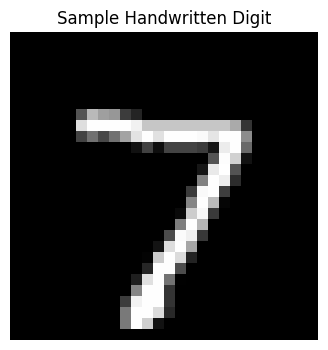

In [ ]:
plt.figure(figsize=(4,4))

plt.imshow(X.iloc[0].values.reshape(28,28), cmap="gray")

plt.title("Sample Handwritten Digit")

plt.axis("off")

plt.show()

In [ ]:
X = X / 255.0

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.20,
                  random_state=42
                  )


In [ ]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [ ]:
model = Sequential([
      Input(shape=(784,)),
          Dense(128, activation="relu"),
              Dense(64, activation="relu"),
                  Dense(10, activation="softmax")
                  ])

In [ ]:
model.compile(
      optimizer="adam",
          loss="categorical_crossentropy",
              metrics=["accuracy"]
              )


In [ ]:
history = model.fit(
      X_train,
          y_train,
              epochs=10,
                  batch_size=32,
                      validation_data=(X_test, y_test),
                          verbose=1
                          )


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8519 - loss: 0.5425 - val_accuracy: 0.9025 - val_loss: 0.3126
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9376 - loss: 0.2124 - val_accuracy: 0.9350 - val_loss: 0.2171
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9589 - loss: 0.1350 - val_accuracy: 0.9390 - val_loss: 0.2027
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9718 - loss: 0.0952 - val_accuracy: 0.9430 - val_loss: 0.2047
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9811 - loss: 0.0661 - val_accuracy: 0.9530 - val_loss: 0.1717
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9886 - loss: 0.0453 - val_accuracy: 0.9555 - val_loss: 0.1706
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9909 - loss: 0.0336 - val_accuracy: 0.9530 - val_loss: 0.1729
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9967 - loss: 0.0171 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9595000147819519


In [ ]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


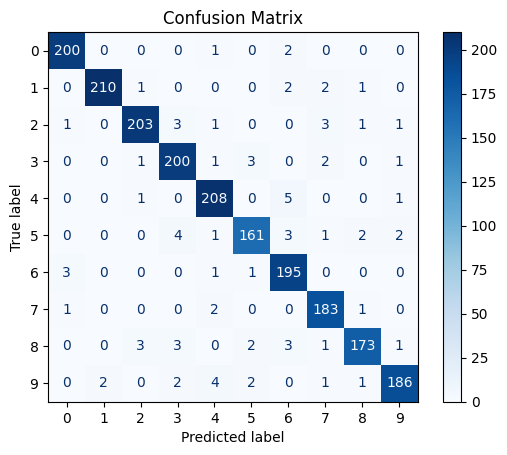

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       203
           1       0.99      0.97      0.98       216
           2       0.97      0.95      0.96       213
           3       0.94      0.96      0.95       208
           4       0.95      0.97      0.96       215
           5       0.95      0.93      0.94       174
           6       0.93      0.97      0.95       200
           7       0.95      0.98      0.96       187
           8       0.97      0.93      0.95       186
           9       0.97      0.94      0.95       198

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



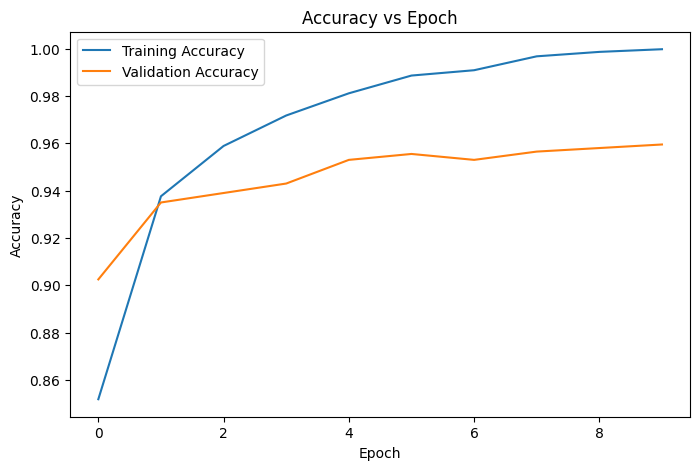

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

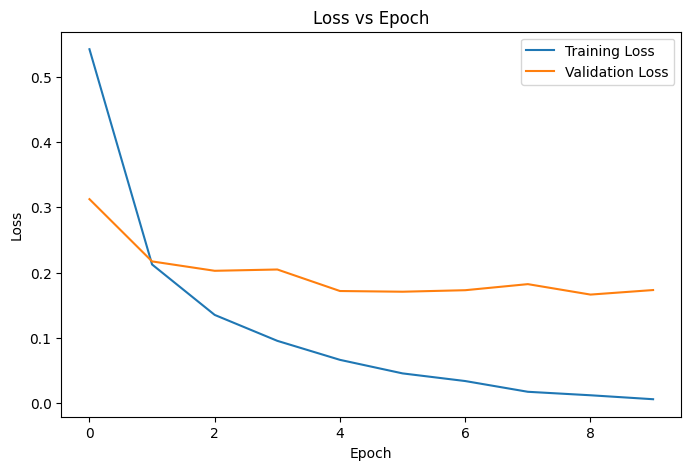

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Observations

1. The ANN model achieved high accuracy in recognizing handwritten digits.

2. Training and validation accuracy increased steadily over the epochs.

3. The confusion matrix showed that most handwritten digits were classified correctly, with only a few misclassifications.

4. Hidden layers helped the network learn complex image patterns, improving classification performance.

## Conclusion

In this assignment, an Artificial Neural Network (ANN) was developed to recognize handwritten digits using the MNIST dataset. The data was preprocessed by normalizing pixel values, splitting it into training and testing sets, and converting the target labels into one-hot encoded vectors. The ANN consisted of two hidden layers with ReLU activation and an output layer with Softmax activation. The model was trained using the Adam optimizer and categorical cross-entropy loss for 10 epochs. The trained model achieved high classification accuracy. Hidden layers enabled the network to learn complex image features effectively. Deep learning provides superior feature learning compared to traditional machine learning methods, although ANN models require more computational resources and longer training time. 0